In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('cryptocurrency.csv')
df.head()

,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap
0,2025-10-08 18:44:50,Figure Heloc,figr_heloc,$0.99,"$9,120,505.00",0.00%,-1.03%,-4.44%,"$12,782,734,116"
1,2025-10-08 18:44:50,LEO Token,leo,$9.66,"$710,525.00",0.00%,-0.08%,+0.62%,"$8,910,328,661"
2,2025-10-08 18:44:50,USDS,usds,$1.00,"$11,359,506.00",0.00%,+0.01%,+0.01%,"$7,936,188,654"
3,2025-10-08 18:44:50,Lido Staked Ether,steth,"$4,453.86","$43,555,003.00",0.01%,-1.41%,+3.64%,"$37,991,861,144"
4,2025-10-08 18:44:50,Wrapped stETH,wsteth,"$5,413.73","$22,328,336.00",0.01%,-1.39%,+3.00%,"$17,567,793,195"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111846 entries, 0 to 111845
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   timestamp   111846 non-null  object
 1   name        111846 non-null  object
 2   symbol      111846 non-null  object
 3   price_usd   111846 non-null  object
 4   vol_24h     111846 non-null  object
 5   total_vol   111846 non-null  object
 6   chg_24h     111846 non-null  object
 7   chg_7d      111830 non-null  object
 8   market_cap  111810 non-null  object
dtypes: object(9)
memory usage: 7.7+ MB


In [ ]:
df.shape

(111846, 9)

In [ ]:
df.describe()

,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap
count,111846,111846,111846,111846,111846,111846,111846,111830,111810
unique,5152,283,307,67286,58157,3060,3086,6518,30090
top,2025-10-04 10:36:10,USDC,USDT,$1.00,$1.01B,0.00%,+0.01%,+0.01%,$8.30B
freq,250,5147,4890,2115,202,5606,2511,2135,258


In [ ]:
df.isnull().sum()

,0
timestamp,0
name,0
symbol,0
price_usd,0
vol_24h,0
total_vol,0
chg_24h,0
chg_7d,16
market_cap,36


# Data Cleaning


In [ ]:
df['price_usd'].unique()

array(['$0.99', '$9.66', '$1.00', ..., '82,953.80', '1,897.14', '9.664'],
      dtype=object)

In [ ]:
df['market_cap'].unique()

array(['$12,782,734,116', '$8,910,328,661', '$7,936,188,654', ...,
       '$133.65B', '$227.30B', '$228.07B'], dtype=object)

In [ ]:
df['chg_24h'].unique()

array(['-1.03%', '-0.08%', '+0.01%', ..., '-16.91%', '-16.82%', '-11.45%'],
      dtype=object)

In [ ]:
df['vol_24h'].unique()

array(['$9,120,505.00', '$710,525.00', '$11,359,506.00', ..., '$431.15M',
       '$447.16M', '$314.52M'], dtype=object)

In [ ]:
def convert_currency(val):
    if pd.isna(val): return None
    val = str(val).replace('$','').replace(',','').replace('%','').strip()
    if val.endswith('K'):
        return float(val[:-1]) * 1_000
    elif val.endswith('M'):
        return float(val[:-1]) * 1_000_000
    elif val.endswith('B'):
        return float(val[:-1]) * 1_000_000_000
    elif val.endswith('T'):
        return float(val[:-1]) * 1_000_000_000_000
    else:
        return float(val)

In [ ]:
cols_to_clean=['price_usd','vol_24h','market_cap','chg_24h','chg_7d','total_vol']
for c in cols_to_clean:
  df[c]=df[c].apply(convert_currency)

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df.head()

,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap
0,2025-10-08 18:44:50,Figure Heloc,figr_heloc,0.99,9120505.0,0.00,-1.03,-4.44,1.278273e+10
1,2025-10-08 18:44:50,LEO Token,leo,9.66,710525.0,0.00,-0.08,0.62,8.910329e+09
2,2025-10-08 18:44:50,USDS,usds,1.00,11359506.0,0.00,0.01,0.01,7.936189e+09
3,2025-10-08 18:44:50,Lido Staked Ether,steth,4453.86,43555003.0,0.01,-1.41,3.64,3.799186e+10
4,2025-10-08 18:44:50,Wrapped stETH,wsteth,5413.73,22328336.0,0.01,-1.39,3.00,1.756779e+10


In [ ]:
df['Day']=df['timestamp'].dt.day
df['Month']=df['timestamp'].dt.month
df['Year']=df['timestamp'].dt.year
df.head()

,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap,Day,Month,Year
0,2025-10-08 18:44:50,Figure Heloc,figr_heloc,0.99,9120505.0,0.00,-1.03,-4.44,1.278273e+10,8,10,2025
1,2025-10-08 18:44:50,LEO Token,leo,9.66,710525.0,0.00,-0.08,0.62,8.910329e+09,8,10,2025
2,2025-10-08 18:44:50,USDS,usds,1.00,11359506.0,0.00,0.01,0.01,7.936189e+09,8,10,2025
3,2025-10-08 18:44:50,Lido Staked Ether,steth,4453.86,43555003.0,0.01,-1.41,3.64,3.799186e+10,8,10,2025
4,2025-10-08 18:44:50,Wrapped stETH,wsteth,5413.73,22328336.0,0.01,-1.39,3.00,1.756779e+10,8,10,2025


In [ ]:
df_copy=df.copy()

In [ ]:
df_copy.drop(columns=['timestamp'],inplace=True)

In [ ]:
df_copy.head()

,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap,Day,Month,Year
0,Figure Heloc,figr_heloc,0.99,9120505.0,0.00,-1.03,-4.44,1.278273e+10,8,10,2025
1,LEO Token,leo,9.66,710525.0,0.00,-0.08,0.62,8.910329e+09,8,10,2025
2,USDS,usds,1.00,11359506.0,0.00,0.01,0.01,7.936189e+09,8,10,2025
3,Lido Staked Ether,steth,4453.86,43555003.0,0.01,-1.41,3.64,3.799186e+10,8,10,2025
4,Wrapped stETH,wsteth,5413.73,22328336.0,0.01,-1.39,3.00,1.756779e+10,8,10,2025


In [ ]:
df_copy.to_csv('cryptocurrency_csv')

# Duplicates


In [ ]:
df_copy.drop_duplicates(inplace=True)

In [ ]:
df_copy.shape

(110962, 11)

In [ ]:
df_copy.columns=[c.lower().strip() for c in df_copy.columns]

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110962 entries, 0 to 111845
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   name        110962 non-null  object 
 1   symbol      110962 non-null  object 
 2   price_usd   110962 non-null  float64
 3   vol_24h     110962 non-null  float64
 4   total_vol   110962 non-null  float64
 5   chg_24h     110961 non-null  float64
 6   chg_7d      110928 non-null  float64
 7   market_cap  110926 non-null  float64
 8   day         110962 non-null  int32  
 9   month       110962 non-null  int32  
 10  year        110962 non-null  int32  
dtypes: float64(6), int32(3), object(2)
memory usage: 8.9+ MB


In [ ]:
df_copy['total_vol'].astype(float)

,total_vol
0,0.00
1,0.00
2,0.00
3,0.01
4,0.01
...,...
111841,31.82
111842,8.43
111843,14.98
111844,0.01


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110962 entries, 0 to 111845
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   name        110962 non-null  object 
 1   symbol      110962 non-null  object 
 2   price_usd   110962 non-null  float64
 3   vol_24h     110962 non-null  float64
 4   total_vol   110962 non-null  float64
 5   chg_24h     110961 non-null  float64
 6   chg_7d      110928 non-null  float64
 7   market_cap  110926 non-null  float64
 8   day         110962 non-null  int32  
 9   month       110962 non-null  int32  
 10  year        110962 non-null  int32  
dtypes: float64(6), int32(3), object(2)
memory usage: 8.9+ MB


In [ ]:
df_copy.head()

,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap,day,month,year
0,Figure Heloc,figr_heloc,0.99,9120505.0,0.00,-1.03,-4.44,1.278273e+10,8,10,2025
1,LEO Token,leo,9.66,710525.0,0.00,-0.08,0.62,8.910329e+09,8,10,2025
2,USDS,usds,1.00,11359506.0,0.00,0.01,0.01,7.936189e+09,8,10,2025
3,Lido Staked Ether,steth,4453.86,43555003.0,0.01,-1.41,3.64,3.799186e+10,8,10,2025
4,Wrapped stETH,wsteth,5413.73,22328336.0,0.01,-1.39,3.00,1.756779e+10,8,10,2025


In [ ]:
df_copy.to_csv('cryptocurrency_cleaned.csv')

# Explore Data

In [ ]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features : ['price_usd', 'vol_24h', 'total_vol', 'chg_24h', 'chg_7d', 'market_cap', 'day', 'month', 'year']

We have 2 categorical features : ['name', 'symbol']


In [ ]:
df=pd.read_csv('cryptocurrency_cleaned.csv')
df.head()

,Unnamed: 0,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap,day,month,year
0,0,Figure Heloc,figr_heloc,0.99,9120505.0,0.00,-1.03,-4.44,1.278273e+10,8,10,2025
1,1,LEO Token,leo,9.66,710525.0,0.00,-0.08,0.62,8.910329e+09,8,10,2025
2,2,USDS,usds,1.00,11359506.0,0.00,0.01,0.01,7.936189e+09,8,10,2025
3,3,Lido Staked Ether,steth,4453.86,43555003.0,0.01,-1.41,3.64,3.799186e+10,8,10,2025
4,4,Wrapped stETH,wsteth,5413.73,22328336.0,0.01,-1.39,3.00,1.756779e+10,8,10,2025


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
name,0
symbol,0
price_usd,0
vol_24h,0
total_vol,0
chg_24h,1
chg_7d,34
market_cap,36
day,0


In [10]:
df = df.dropna(subset=['chg_24h', 'chg_7d', 'market_cap'])

# MARKET OVERVIEW



TOP 10 COIN MARKET CAP

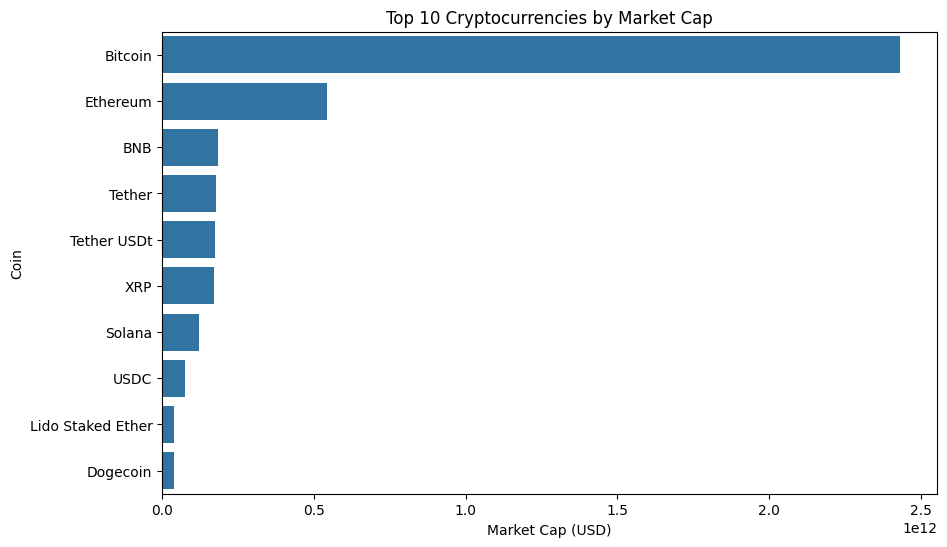

In [13]:
latest = df.sort_values(by=['year', 'month', 'day']).drop_duplicates('name', keep='last')
top10 = latest.nlargest(10, 'market_cap')

plt.figure(figsize=(10,6))
sns.barplot(x='market_cap', y='name', data=top10)
plt.title('Top 10 Cryptocurrencies by Market Cap')
plt.xlabel('Market Cap (USD)')
plt.ylabel('Coin')
plt.show()



MARKET CAP & VOLUME

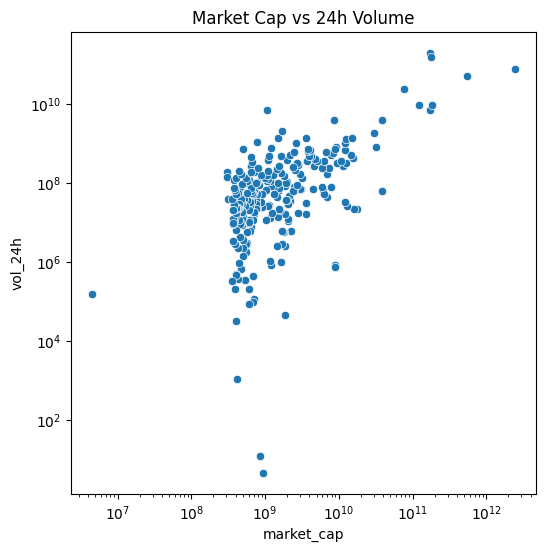

In [14]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='market_cap', y='vol_24h', data=latest)
plt.xscale('log'); plt.yscale('log')
plt.title('Market Cap vs 24h Volume')
plt.show()

# TIME SERIES

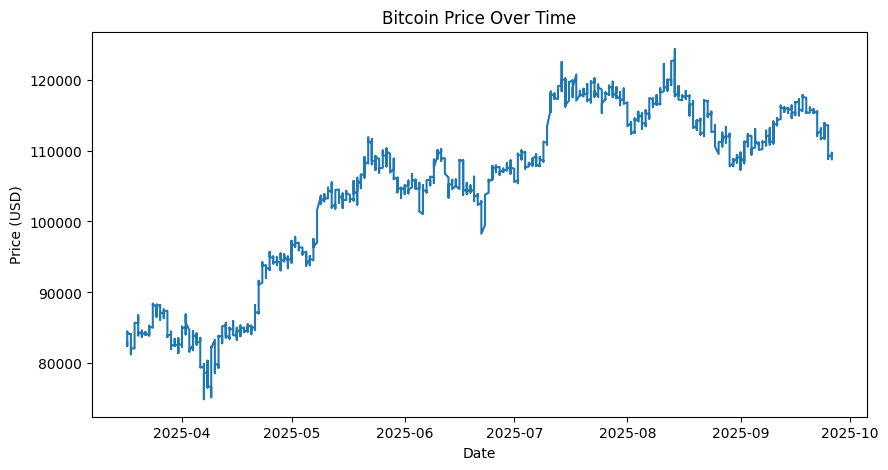

In [23]:
btc = df[df['symbol'] == 'BTC']
btc['Date'] = pd.to_datetime(btc[['year', 'month', 'day']])
plt.figure(figsize=(10,5))
plt.plot(btc['Date'], btc['price_usd'])
plt.title('Bitcoin Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()



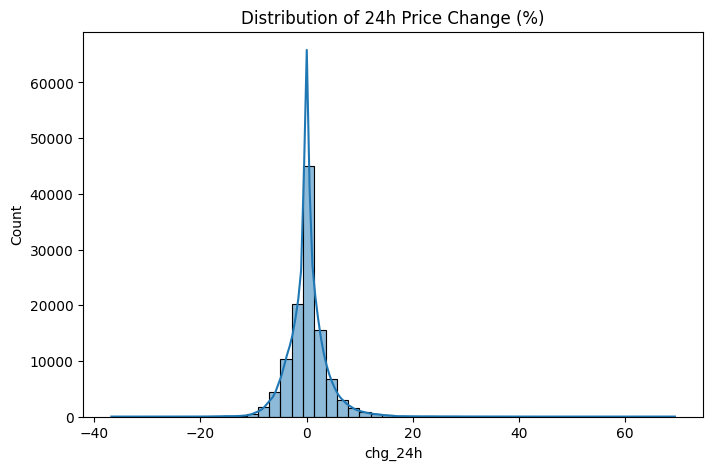

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['chg_24h'], bins=50, kde=True)
plt.title('Distribution of 24h Price Change (%)')
plt.show()


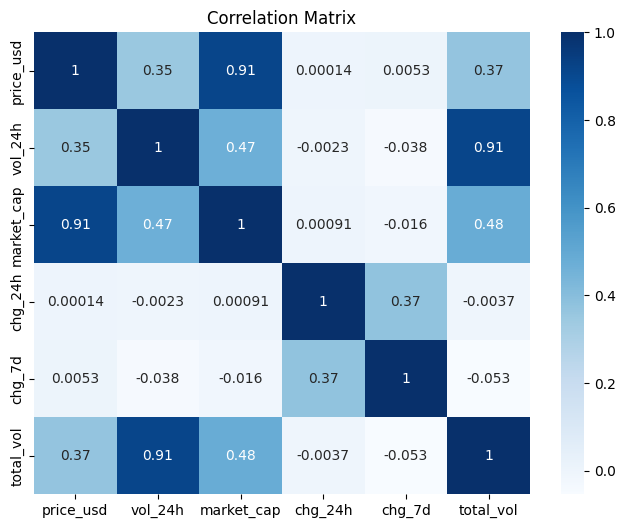

In [24]:
corr = df[['price_usd','vol_24h','market_cap','chg_24h','chg_7d','total_vol']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

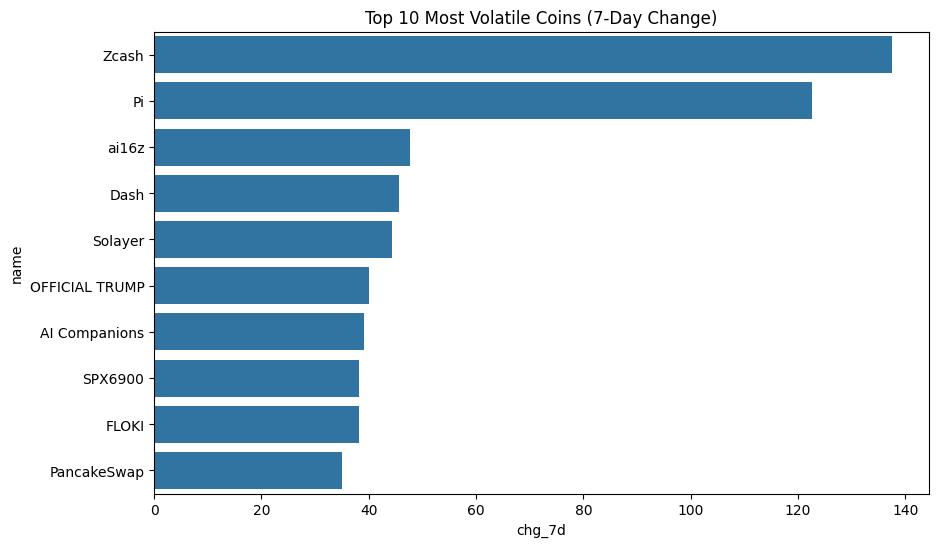

In [25]:
vola = latest.nlargest(10, 'chg_7d')
plt.figure(figsize=(10,6))
sns.barplot(x='chg_7d', y='name', data=vola)
plt.title('Top 10 Most Volatile Coins (7-Day Change)')
plt.show()

INSIGHTS

- The market is highly concentrated, with Bitcoin and Ethereum accounting for the majority of total market capitalization.

- Most cryptocurrencies fluctuate within a ±5% daily range, while small-cap altcoins show extreme volatility.

- There is a strong positive correlation between market capitalization and 24-hour trading volume, indicating higher liquidity in large coins.

- Bitcoin’s price movement tends to drive overall market trends, confirming its role as the market leader.

- A few low-market-cap coins have high volume-to-marketcap ratios, suggesting speculative trading activity.
